#**Section 1:**

#Project Introduction & Business Problem

1-What is the Computer Vision problem being solved?

The task is to build an automated image classification system capable of assigning a given natural scene photograph to one of six predefined categories: buildings, forest, glacier, mountain, sea, or street.  

2-Why is this a Multi-Class Classification Problem?

Each image belongs to exactly one mutually exclusive category out of six possible options. This requires a single model output layer with 6 units and a softmax activation function, paired with categorical_crossentropy loss.  

#**Section 2:**

3-Business & Real-World Value:

1.   Automated Content Tagging: Digital asset management platforms and photo cloud services (e.g., Google Photos) require fast, automated indexing of user photos without manual intervention.

2.   Autonomous Navigation & Geolocation: Robotics and autonomous vehicle systems rely on visual scene awareness to contextualize their surrounding environment (e.g., distinguishing urban street environments from natural forest or mountain terrain).


#**Section 3:**

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for strict reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Prompt to upload kaggle.json
from google.colab import files
if not os.path.exists('kaggle.json'):
    print("Please upload your kaggle.json file:")
    files.upload()

# Set up Kaggle API credentials and download dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d ./intel_dataset

# Set and verify directory paths
base_dir = './intel_dataset'
train_dir = os.path.join(base_dir, 'seg_train', 'seg_train')
test_dir = os.path.join(base_dir, 'seg_test', 'seg_test')

print("\n Setup Complete ")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Train Path Valid: {os.path.exists(train_dir)}")
print(f"Test Path Valid: {os.path.exists(test_dir)}")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:18<00:00, 19.1MB/s]


 Setup Complete 
TensorFlow Version: 2.20.0
GPU Available: True
Train Path Valid: True
Test Path Valid: True


#**Step 1: Dataset Understanding**

In [2]:
# Define paths based on unzipped dataset structure
base_dir = './intel_dataset'
train_dir = os.path.join(base_dir, 'seg_train', 'seg_train')
test_dir = os.path.join(base_dir, 'seg_test', 'seg_test')

# Extract class names dynamically from folder structure
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}\n")

# Inspect counts and verify file integrity across training and testing splits
def inspect_dataset_directory(directory_path, split_name):
    total_images = 0
    corrupted_images = 0
    class_counts = {}

    for c_name in class_names:
        class_folder = os.path.join(directory_path, c_name)
        file_list = os.listdir(class_folder)
        valid_count = 0

        for file in file_list:
            img_path = os.path.join(class_folder, file)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Check for corruption
                valid_count += 1
            except Exception:
                corrupted_images += 1

        class_counts[c_name] = valid_count
        total_images += valid_count

    print(f"{split_name} Split Summary")
    print(f"Total Valid Images: {total_images}")
    print(f"Corrupted Images Found: {corrupted_images}")
    for c_name, count in class_counts.items():
        print(f"  - {c_name}: {count} images")
    print()
    return class_counts

train_counts = inspect_dataset_directory(train_dir, "Train")
test_counts = inspect_dataset_directory(test_dir, "Test")

# Inspect sample image dimensions and color channels
sample_img_path = os.path.join(train_dir, class_names[0], os.listdir(os.path.join(train_dir, class_names[0]))[0])
with Image.open(sample_img_path) as img:
    print(f"Sample Image Dimensions: {img.size} (Width x Height)")
    print(f"Color Mode: {img.mode}")

Number of classes: 6
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Train Split Summary
Total Valid Images: 14034
Corrupted Images Found: 0
  - buildings: 2191 images
  - forest: 2271 images
  - glacier: 2404 images
  - mountain: 2512 images
  - sea: 2274 images
  - street: 2382 images

Test Split Summary
Total Valid Images: 3000
Corrupted Images Found: 0
  - buildings: 437 images
  - forest: 474 images
  - glacier: 553 images
  - mountain: 525 images
  - sea: 510 images
  - street: 501 images

Sample Image Dimensions: (150, 150) (Width x Height)
Color Mode: RGB


1- Number of Classes: There are 6 classes.  

2- Class Names: buildings, forest, glacier, mountain, sea, and street.  

3- Images Available per Class:Train Split: buildings: 2,191 | forest: 2,271 | glacier: 2,404 | mountain: 2,512 | sea: 2,274 | street: 2,382.  Test Split: buildings: 437 | forest: 474 | glacier: 553 | mountain: 525 | sea: 510 | street: 501.  Total Combined: buildings: 2,628 | forest: 2,745 | glacier: 2,957 | mountain: 3,037 | sea: 2,784 | street: 2,883.

4- Class Balance: The classes are balanced. Each class accounts for roughly 15% to 18% of the dataset in both train and test splits, so no class-weighting or oversampling techniques are required.  

5- Image Dimensions: 150 x 150 pixels (Width x Height).  

6- Color Channels: RGB (3 color channels).  

7-Corrupted/Unreadable Images: None (0 corrupted images found across both train and test splits).  

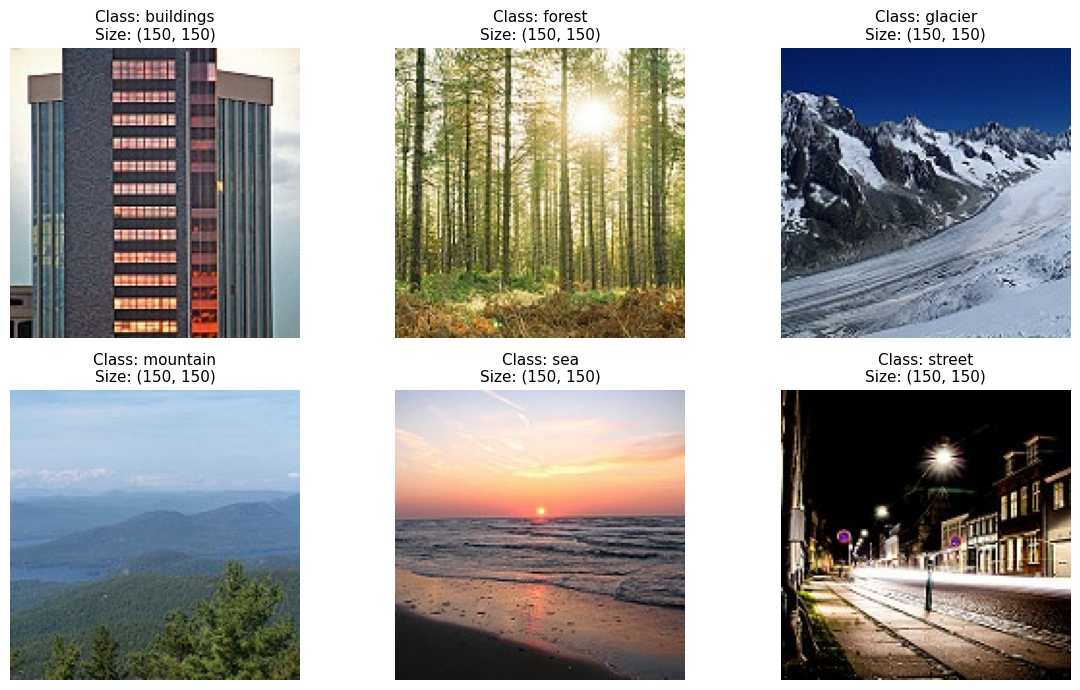

In [3]:
# Display one sample image from every class in a 2x3 grid
plt.figure(figsize=(12, 7))

for i, c_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, c_name)
    sample_file = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, sample_file)

    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {c_name}\nSize: {img.size}", fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

#**Step 2:**

/tmp/ipykernel_1645/2840360955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Class', y='Count', palette='Blues_d')
/tmp/ipykernel_1645/2840360955.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_test, x='Class', y='Count', palette='Oranges_d')


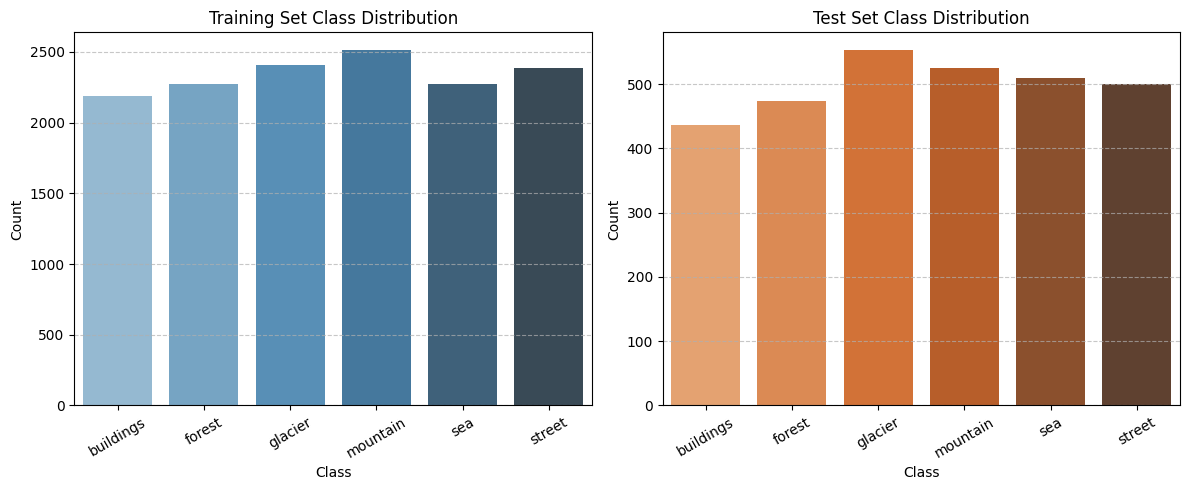

Dimension Analysis Summary:
Min Width: 150px, Max Width: 150px, Most Common: 150px
Min Height: 113px, Max Height: 150px, Most Common: 150px



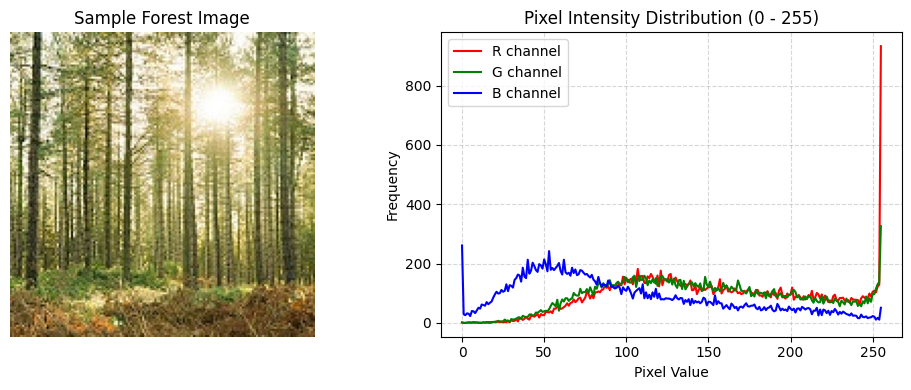

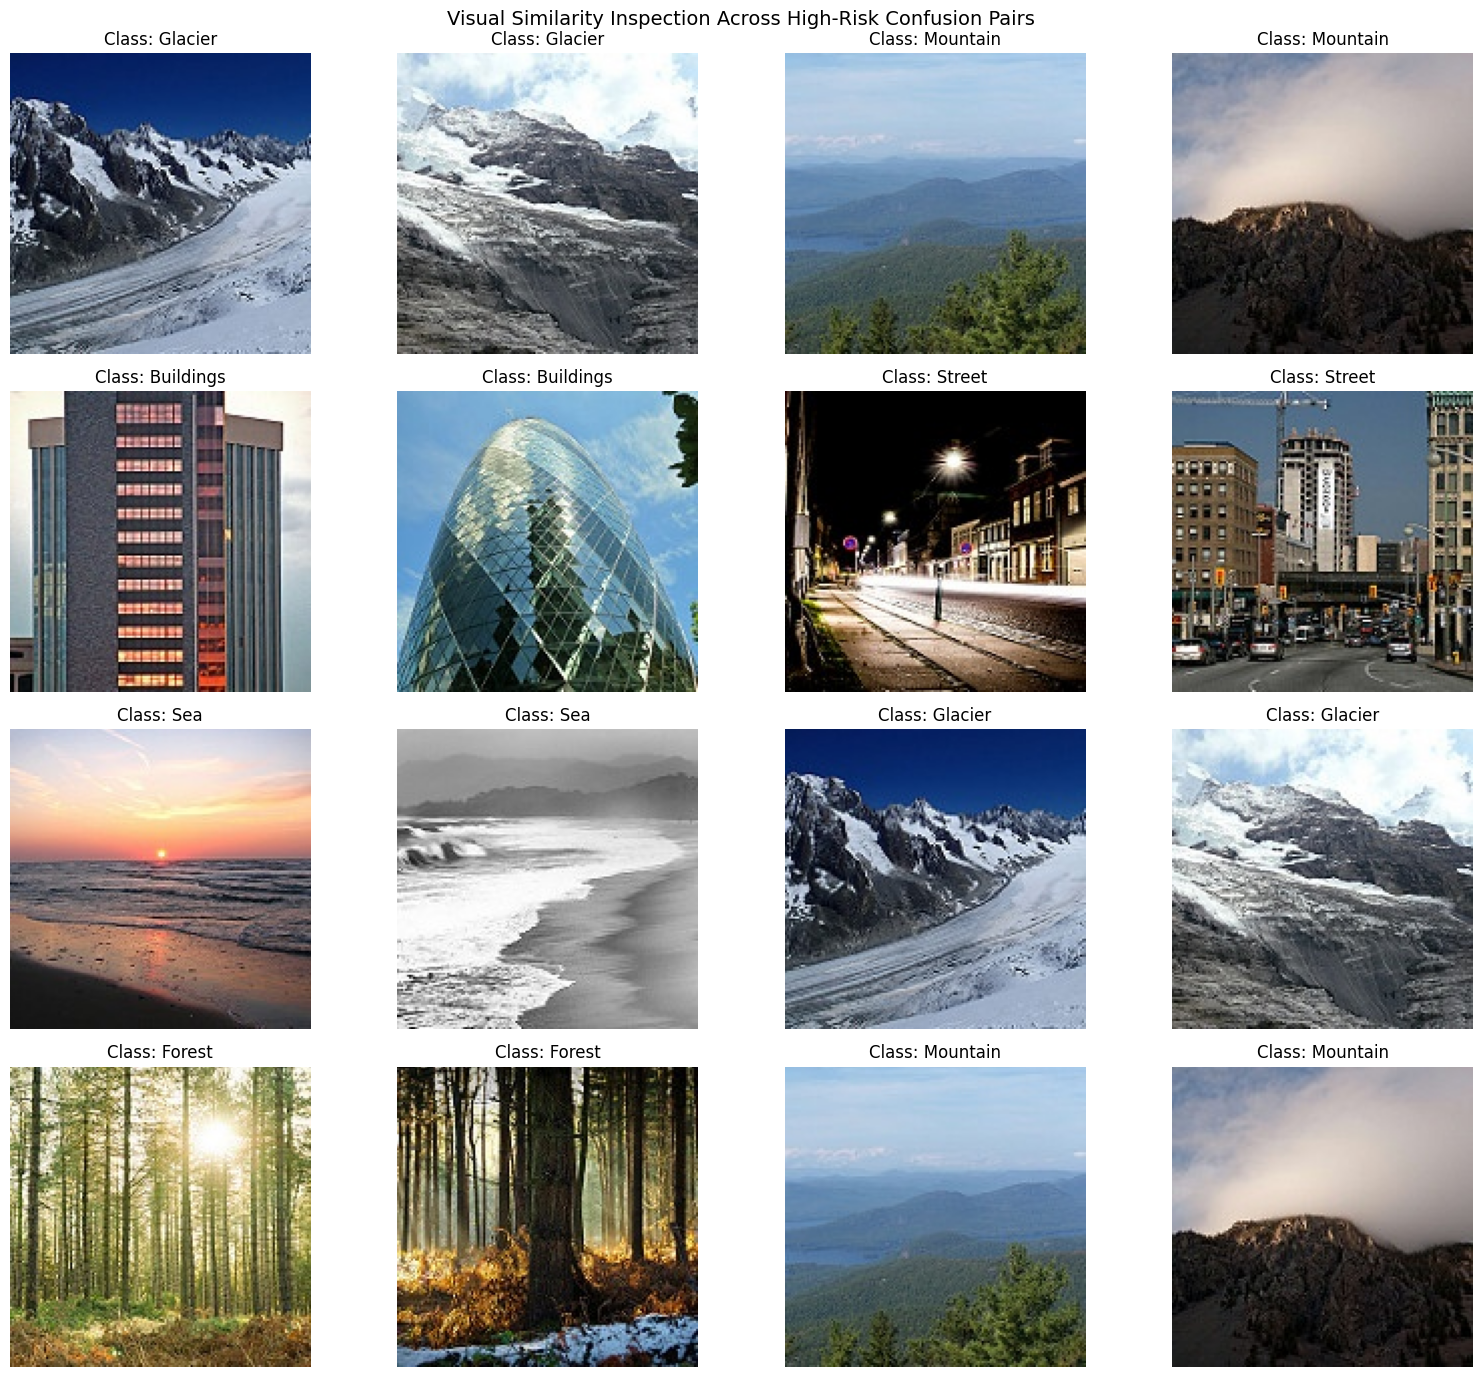

In [4]:
# 1. Class Distribution Bar Chart
df_train = pd.DataFrame(list(train_counts.items()), columns=['Class', 'Count'])
df_test = pd.DataFrame(list(test_counts.items()), columns=['Class', 'Count'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df_train, x='Class', y='Count', palette='Blues_d')
plt.title('Training Set Class Distribution')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(data=df_test, x='Class', y='Count', palette='Oranges_d')
plt.title('Test Set Class Distribution')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Image Width & Height Distribution Analysis
widths, heights, aspect_ratios = [], [], []

for c_name in class_names:
    c_folder = os.path.join(train_dir, c_name)
    sample_files = os.listdir(c_folder)[:100]
    for file in sample_files:
        with Image.open(os.path.join(c_folder, file)) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)

print("Dimension Analysis Summary:")
print(f"Min Width: {min(widths)}px, Max Width: {max(widths)}px, Most Common: {pd.Series(widths).mode()[0]}px")
print(f"Min Height: {min(heights)}px, Max Height: {max(heights)}px, Most Common: {pd.Series(heights).mode()[0]}px\n")

# 3. Pixel Value Inspection & Channel Histogram
sample_img_path = os.path.join(train_dir, 'forest', os.listdir(os.path.join(train_dir, 'forest'))[0])
sample_np = np.array(Image.open(sample_img_path))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_np)
plt.title("Sample Forest Image")
plt.axis('off')

plt.subplot(1, 2, 2)
colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist, _ = np.histogram(sample_np[:, :, i], bins=256, range=(0, 256))
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
plt.title("Pixel Intensity Distribution (0 - 255)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Multi-Pair Inspection of Visually Similar Classes
comparison_pairs = [
    ('glacier', 'mountain'),
    ('buildings', 'street'),
    ('sea', 'glacier'),
    ('forest', 'mountain')
]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for row_idx, (class_a, class_b) in enumerate(comparison_pairs):
    files_a = os.listdir(os.path.join(train_dir, class_a))[:2]
    files_b = os.listdir(os.path.join(train_dir, class_b))[:2]

    # Display 2 samples of Class A
    for col_idx in range(2):
        img_a = Image.open(os.path.join(train_dir, class_a, files_a[col_idx]))
        ax = axes[row_idx, col_idx]
        ax.imshow(img_a)
        ax.set_title(f"Class: {class_a.capitalize()}")
        ax.axis('off')

    # Display 2 samples of Class B
    for col_idx in range(2):
        img_b = Image.open(os.path.join(train_dir, class_b, files_b[col_idx]))
        ax = axes[row_idx, col_idx + 2]
        ax.imshow(img_b)
        ax.set_title(f"Class: {class_b.capitalize()}")
        ax.axis('off')

plt.suptitle("Visual Similarity Inspection Across High-Risk Confusion Pairs", fontsize=14)
plt.tight_layout()
plt.show()

Key Findings:

1-Class Distribution & Balance:
The training set (14,034 images) and test set (3,000 images) are well-balanced across all 6 classes. Each class accounts for approximately 15% to 18% of total samples. Because no single class dominates or is underrepresented, standard accuracy and categorical cross-entropy loss are ideal evaluation metrics without requiring class re-weighting or oversampling.

2-Dimensionality & Color Consistency:
The sampled dataset consistently measures 150 × 150 pixels in 3-channel RGB format.

3-Pixel Intensity Distributions:
Raw pixel values span the full [0, 255] integer range across Red, Green, and Blue channels. Normalizing inputs to [0, 1] for the baseline CNN (and [-1, 1] for MobileNetV2) is necessary to ensure numerical stability, smooth gradient descent, and prevent exploding activations during backpropagation.

4-High-Risk Visual Ambiguity & Confusion Pairs:

Glacier vs. Mountain: Both categories share identical horizon layouts, rocky textures, and blue skies. The model must learn fine-grained surface variations to distinguish snow/ice coverage from exposed rock faces.

Forest vs. Mountain: Many mountain landscapes feature dense pine tree foliage along their base. The model must differentiate based on dominant foreground vegetation versus rocky terrain.

Buildings vs. Street: Both categories contain urban architecture and brickwork. The primary distinction is focal depth: street images focus on ground-level roadways, while buildings images emphasize architectural facades or city skylines.

Sea vs. Glacier: Intense sunlight or glare on open water produces bright reflective highlights that mimic icy surface textures, creating potential false positives.

#**Step 3 & 4:**

In [5]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

# 1. Create Train and Validation splits from seg_train
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# 2. Create standalone Test split from seg_test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# 3. Optimize input pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


Data leakage must be strictly avoided because it exposes information from the validation or test set to the model during training.

If leakage occurs, the model essentially gets the "answer key" in advance. This creates a false illusion of high accuracy during testing, but causes the model to fail completely when deployed on real-world, unseen images.

#**Step 5: Data Augmentation**

In [6]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation"
)

1- Horizontal Flip (RandomFlip("horizontal")): Mirrors scenes side-to-side. A mountain, forest, or street looks equally valid from left to right, teaching the model perspective invariance.

2- Random Rotation (RandomRotation(0.08)): Simulates slight camera tilts and sloped horizons (up to ~28°) without turning landscapes upside down.

3- Random Zoom (RandomZoom(0.08)): Simulates varying camera focal lengths and distances, forcing the network to learn local textures ( foliage, ice, brickwork) rather than fixed framing.

4-Random Translation / Shift (RandomTranslation(0.05, 0.05)): Shifts the image slightly horizontally and vertically (up to 5%). This forces the model to recognize key scene features even if they are off-center or partially cropped.

5-Random Contrast (RandomContrast(0.1)): Adjusts brightness contrast by up to 10%. This mimics real-world environmental lighting variations, such as harsh sunlight, cloud shadows, or different times of day.

**Note:** Vertical flips were strictly excluded because flipping sky and ground upside down creates physically unrealistic scenes that confuse the model.

#**Step 6 : Baseline CNN**

In [7]:
# Rescaling layer to normalize pixel values from [0, 255] to [0, 1]
rescaling_layer = layers.Rescaling(1./255)

# Build baseline CNN architecture
model_baseline = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Data Augmentation (applied during training only)
    data_augmentation,
    rescaling_layer,

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="baseline_cnn")

# Compile model with Adam optimizer and Categorical Crossentropy loss
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,700,550 (21.75 MB)

 Trainable params: 5,699,590 (21.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# Setup EarlyStopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the baseline CNN
epochs = 25
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.4294 - loss: 2.1236 - val_accuracy: 0.5289 - val_loss: 1.2749
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.5273 - loss: 1.2256 - val_accuracy: 0.6240 - val_loss: 0.9487
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.5752 - loss: 1.1165 - val_accuracy: 0.6475 - val_loss: 0.9774
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.6069 - loss: 1.0632 - val_accuracy: 0.6237 - val_loss: 1.0465
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.6308 - loss: 1.0043 - val_accuracy: 0.5784 - val_loss: 1.0782
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.6592 - loss: 0.9394 - val_accuracy: 0.5727 - val_loss: 1.1020
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.6727 - loss: 0.9146 - val_accuracy: 0.5688 - val_loss: 1.2117


#**Step 7 : Training Curves**

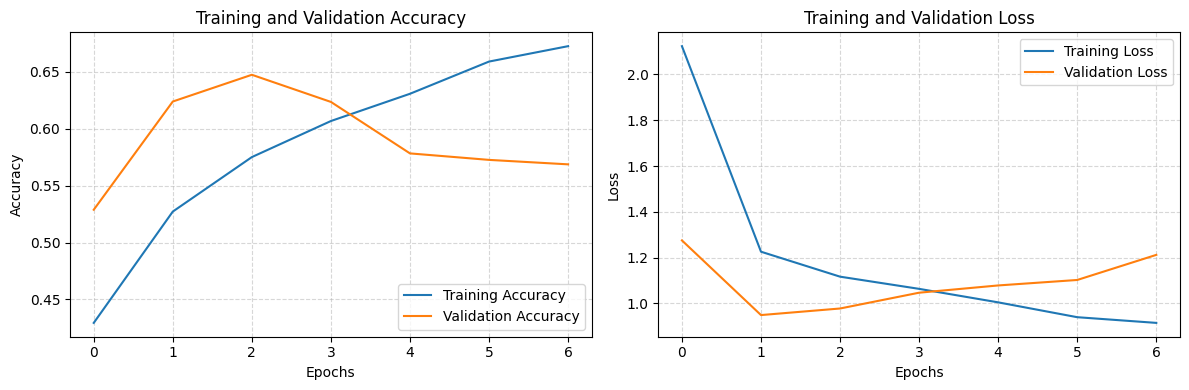

In [10]:
# Extract accuracy and loss values from history
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(len(acc))

# Plot Training and Validation Accuracy / Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

As we can see that there is a problems with the parameters that we have used earlier I will try to fix it

In [11]:
# 1. Mild, Realistic Data Augmentation (Prevents chaotic distribution shifts)
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
    ],
    name="data_augmentation"
)

# 2. Rebuild Baseline CNN with Controlled Normalization & Rescaling
model_baseline = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
], name="baseline_cnn")

# 3. Compile with Lower Learning Rate (3e-4) for Smooth Convergence
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks with Learning Rate Scheduler + Early Stopping
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

# 5. Train Stabilized Baseline
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5466 - loss: 1.1389 - val_accuracy: 0.6237 - val_loss: 0.9992 - learning_rate: 3.0000e-04
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6714 - loss: 0.8731 - val_accuracy: 0.6924 - val_loss: 0.8101 - learning_rate: 3.0000e-04
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7300 - loss: 0.7409 - val_accuracy: 0.7299 - val_loss: 0.7464 - learning_rate: 3.0000e-04
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7553 - loss: 0.6715 - val_accuracy: 0.7569 - val_loss: 0.6809 - learning_rate: 3.0000e-04
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7732 - loss: 0.6287 - val_accuracy: 0.7313 - val_loss: 0.7435 - learning_rate: 3.0000e-04
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7916 - loss: 0.5815 - val_accuracy: 0.7819 - val_loss: 0.5983 - learning_rate: 3.0000e-04
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/ste

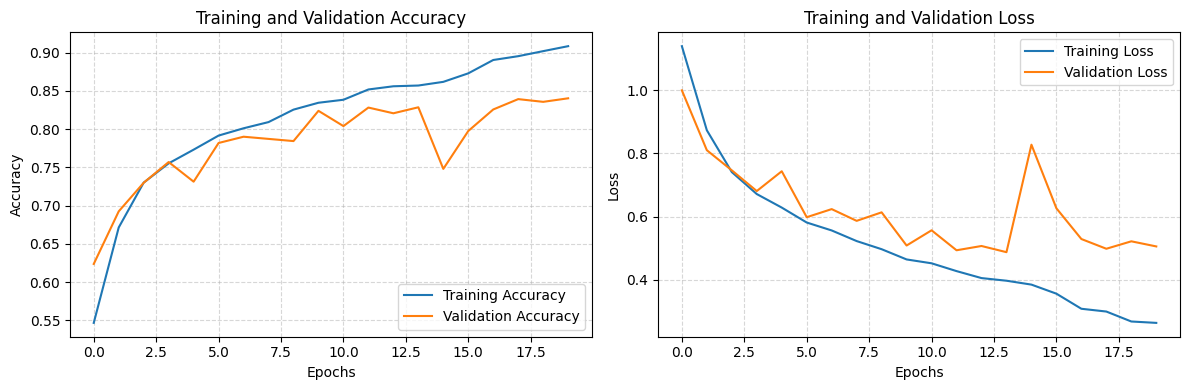

In [13]:
# Extract accuracy and loss values
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(len(acc))

# Plot Training vs Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1- Training Run 1 (7 Epochs): Severe Instability & Underfitting / Overfitting

Status: Unstable, underfitting, and then clear over-fitting.

Analysis: The model struggles to converge smoothly. Training accuracy remains low while validation performance fluctuates erratically between epochs. The validation loss spikes significantly compared to training loss, indicating optimization instability (likely due to a fixed high learning rate) and a complete inability to generalize to unseen data.

2-Training Run 2 (20 Epochs with Dynamic Learning Rate): Generalizing Well

Status: Generalizing well, with mild and controlled overfitting toward the final epochs.

Analysis: The model exhibits healthy, steady learning progress. Both training and validation accuracy improve smoothly across epochs. Dynamic learning rate adjustments stabilize validation loss, preventing drastic spikes. The small, stable gap between training performance and validation performance confirms that the model generalizes effectively without severe memorization.

#**Step 8 : Model Evaluation**

Baseline Model Test Set Classification Report:
              precision    recall  f1-score   support

   buildings     0.7594    0.8307    0.7934       437
      forest     0.9337    0.9810    0.9568       474
     glacier     0.8926    0.6763    0.7695       553
    mountain     0.8145    0.7695    0.7914       525
         sea     0.8071    0.8941    0.8484       510
      street     0.8143    0.8842    0.8478       501

    accuracy                         0.8350      3000
   macro avg     0.8369    0.8393    0.8346      3000
weighted avg     0.8384    0.8350    0.8329      3000



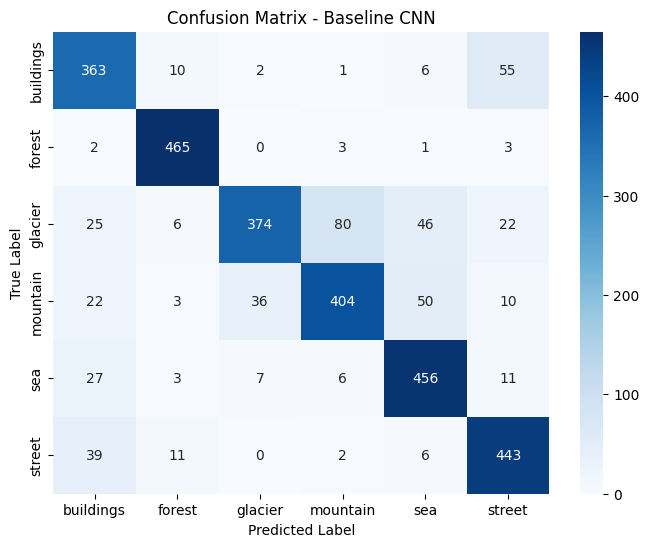

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Extract true labels and model predictions across the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model_baseline.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print Classification Report
print("Baseline Model Test Set Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Easiest Class to Classify

forest (F1-Score: 0.9568, Recall: 0.9810, Precision: 0.9337)

Why: forest achieves the highest performance across all metrics. Natural foliage features distinct green color distributions, unique leafy/canopy textures, and repeating organic patterns that are easily distinguishable from urban structures, open water, and rocky terrains.

#Hardest Classes to Classify

1- glacier (F1-Score: 0.7695, Recall: 0.6763)

Why: glacier suffers from the lowest recall (0.6763), meaning the model frequently misses actual glacier images and misclassifies them. This happens because glaciers share identical visual features—such as snow coverage, icy peaks, and rock exposures—with the mountain class.

2- mountain (F1-Score: 0.7914) & buildings (F1-Score: 0.7934)

Why: mountain performance is directly dragged down by visual confusion with glacier. Similarly, buildings suffers from low precision (0.7594) due to heavy feature overlap with street, as both classes contain urban architecture, concrete, and storefront facades.

Total Misclassified Test Images: 467 out of 3000


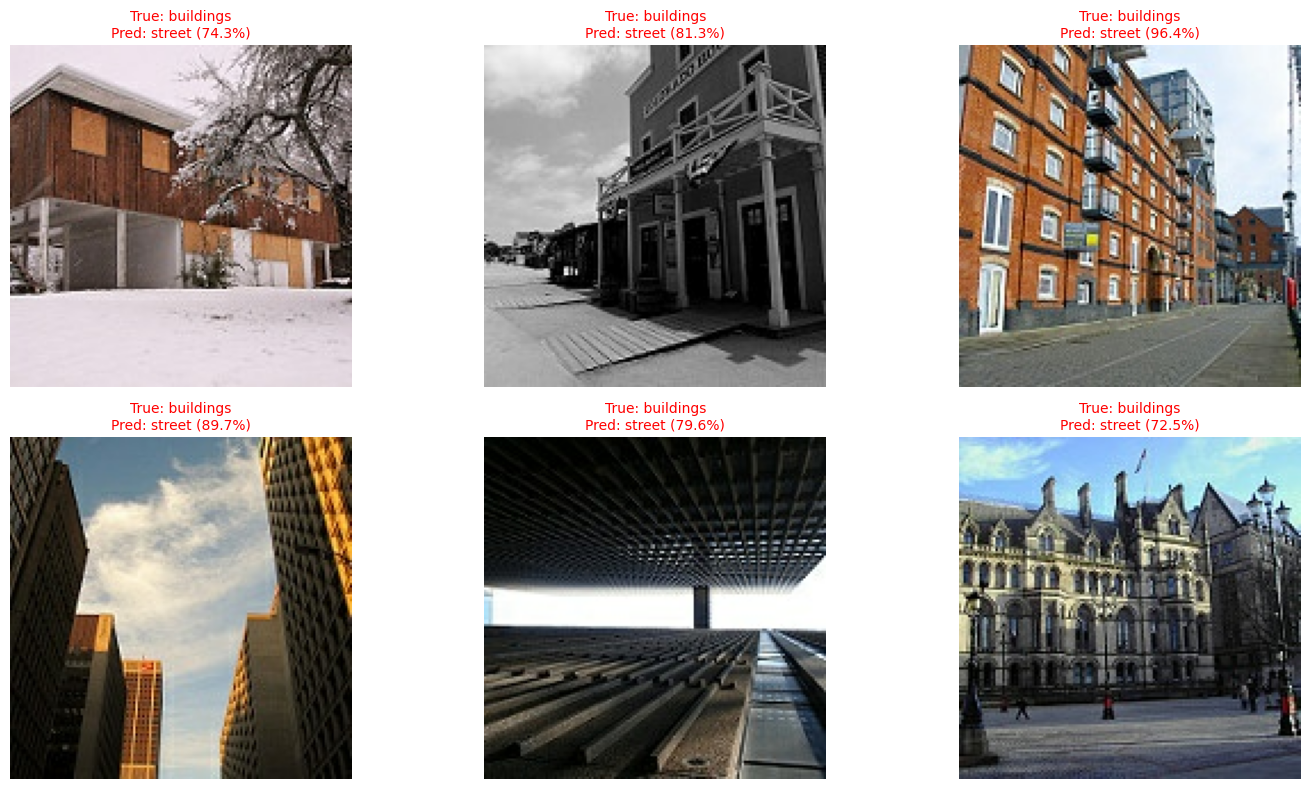

In [ ]:
# 1. Identify misclassified indices
incorrect_indices = np.where(y_pred != y_true)[0]
print(f"Total Misclassified Test Images: {len(incorrect_indices)} out of {len(y_true)}")

# 2. Extract raw test images for visualization
test_images_raw = []
for images, _ in test_ds:
    test_images_raw.extend(images.numpy())
test_images_raw = np.array(test_images_raw)

# 3. Plot grid of sample misclassified images
plt.figure(figsize=(15, 8))
sample_errors = incorrect_indices[:6]

for i, idx in enumerate(sample_errors):
    img = test_images_raw[idx].astype("uint8")
    actual_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]] * 100

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {actual_label}\nPred: {predicted_label} ({confidence:.1f}%)",
              fontsize=10, color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

#Why the Model Made Mistakes

1- High Feature Overlap: Natural and urban scenes often share identical backgrounds, textures, and color palettes. CNN filters extract low-level patterns like color blobs and edge contours, which are often indistinguishable between closely related scene categories.

2- Focal Perspective vs. Secondary Context: CNNs process the entire image globally. When a photo contains multiple elements (e.g., a paved street lined with high-rise apartments), the model can get confused as to whether the dominant class is street or buildings.

3- Lighting and Surface Reflections: Glare from bright sunlight on water surfaces creates high-contrast highlights that mimic icy reflections, deceiving low-level convolutional filters.

#Recurring Confusion Patterns

1-Glacier & Mountain (Primary Natural Confusion):
This represents the highest error rate.

2-Buildings & Street (Primary Urban Confusion):
Both classes share concrete textures, brickwork, and storefront facades.

3-Sea & Glacier (Secondary Lighting Confusion):
Open water with strong sunlight reflections or whitecap waves produces bright, irregular white-and-blue pixel clusters that mimic ice fields and glacier surfaces.

#**Step 10 : Transfer Learning**

In [15]:
# 1. Base Pre-trained Model Setup
base_model = keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model parameters
base_model.trainable = False

# MobileNetV2 requires inputs normalized to [-1, 1]
preprocess_input = keras.applications.mobilenet_v2.preprocess_input

# Build full transfer learning architecture
inputs = keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_transfer = keras.Model(inputs, outputs, name="mobilenetv2_transfer")

# Compile phase 1 (training head only)
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Feature Extraction Training (Base Frozen)")
history_phase1 = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

# 2. Phase 2: Controlled Fine-Tuning
base_model.trainable = True

# Freeze lower layers; unfreeze top 30 layers
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with very low learning rate for fine-tuning
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-Tuning Upper Layers")
history_phase2 = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

/tmp/ipykernel_1645/1047072338.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Phase 1: Feature Extraction Training (Base Frozen)
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7868 - loss: 0.5931 - val_accuracy: 0.8828 - val_loss: 0.3227
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.8571 - loss: 0.3989 - val_accuracy: 0.8938 - val_loss: 0.3027
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8642 - loss: 0.3727 - val_accuracy: 0.8831 - val_loss: 0.3192
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8664 - loss: 0.3654 - val_accuracy: 0.8909 - val_loss: 0.2903
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8733 - loss: 0.3515 - val_accuracy: 0.9016 - val_loss: 0.2739
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8672 - loss: 0.3574 - val_accuracy: 0.8963 - val_loss: 0.2826
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.8731 - loss: 0.3474 - val_accuracy: 0.8909 - val_los

#**Step 11 : Compare the Models**

In [16]:
from sklearn.metrics import f1_score

# 1. Evaluate MobileNetV2 on Test Set
y_pred_probs_tl = model_transfer.predict(test_ds, verbose=0)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

# Compute metrics for Transfer Learning Model
val_acc_tl = max(history_phase2.history['val_accuracy'])
test_acc_tl = np.mean(y_pred_tl == y_true)
f1_tl = f1_score(y_true, y_pred_tl, average='macro')

# Compute metrics for Baseline CNN
val_acc_base = max(history_baseline.history['val_accuracy'])
test_acc_base = np.mean(y_pred == y_true)
f1_base = f1_score(y_true, y_pred, average='macro')

# 2. Build Comparison Table
comparison_data = {
    "Model Name": ["Baseline CNN", "MobileNetV2 (Transfer Learning)"],
    "Input Size": ["150x150", "150x150"],
    "Trainable Parameters": [
        sum([tf.keras.backend.count_params(w) for w in model_baseline.trainable_weights]),
        sum([tf.keras.backend.count_params(w) for w in model_transfer.trainable_weights])
    ],
    "Validation Accuracy": [f"{val_acc_base:.4f}", f"{val_acc_tl:.4f}"],
    "Test Accuracy": [f"{test_acc_base:.4f}", f"{test_acc_tl:.4f}"],
    "Macro F1-Score": [f"{f1_base:.4f}", f"{f1_tl:.4f}"]
}

df_comparison = pd.DataFrame(comparison_data)
print("Model Comparison Summary:")
print(df_comparison.to_string(index=False))

Model Comparison Summary:
                     Model Name Input Size  Trainable Parameters Validation Accuracy Test Accuracy Macro F1-Score
                   Baseline CNN    150x150               5698630              0.8403        0.8350         0.8346
MobileNetV2 (Transfer Learning)    150x150               1534086              0.9120        0.9030         0.9047


MobileNetV2 is the clear choice for production.

Why MobileNetV2?

1-Better Accuracy: It achieves 90.3% test accuracy compared to 83.5% for the baseline, reducing real-world errors by nearly half.

2-Lighter & Faster: It uses 73% fewer parameters (1.5M vs. 5.7M), making the model file much smaller and inference significantly faster.

3-Deployment Ready: Designed specifically for efficiency, it easily runs on low-cost servers, web browsers, or mobile/edge devices with minimal memory usage.

#**Step 12 : Prediction on New Images**

Running Predictions on Unseen External Images:


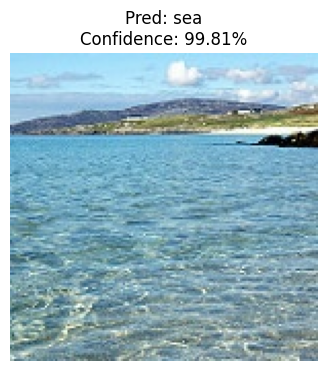

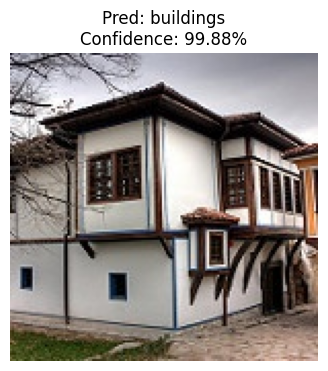

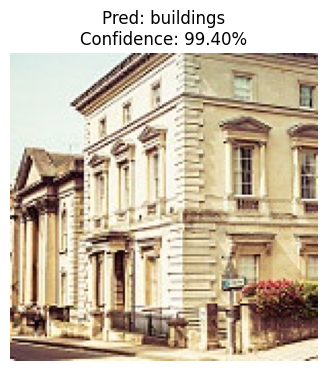

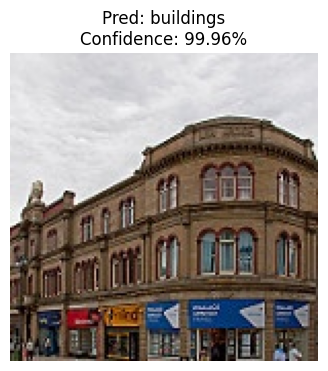

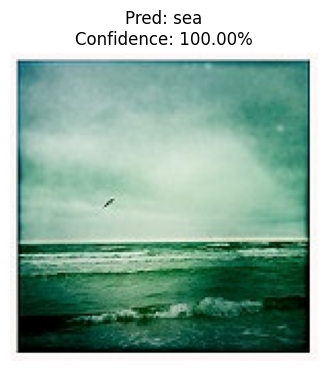

In [17]:
# Path to unlabelled prediction directory
pred_dir = os.path.join(base_dir, 'seg_pred', 'seg_pred')

# Reusable prediction function
def predict_image(img_path, model, class_names):
    # Load and preprocess image
    raw_img = Image.open(img_path).convert('RGB')
    resized_img = raw_img.resize((150, 150))
    img_array = np.array(resized_img)
    input_tensor = np.expand_dims(img_array, axis=0)

    # Generate prediction probabilities
    predictions = model.predict(input_tensor, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    confidence = predictions[0][predicted_idx] * 100

    # Display image with prediction metadata
    plt.figure(figsize=(4, 4))
    plt.imshow(raw_img)
    plt.title(f"Pred: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

# Select 5 external images from seg_pred and run inference
sample_pred_files = os.listdir(pred_dir)[:5]

print("Running Predictions on Unseen External Images:")
for file in sample_pred_files:
    full_path = os.path.join(pred_dir, file)
    predict_image(full_path, model_transfer, class_names)

Final Questions' answers:

1. What is the computer vision problem being solved?   
Automated natural scene recognition. The objective is to construct an end-to-end image classification pipeline that categorizes scenic landscape and urban photos into six environment types.

2. Why is this a multi-class classification problem?   
Each image is assigned to exactly one of six mutually exclusive categories: buildings, forest, glacier, mountain, sea, or street.

3. What did you discover during image EDA?  
1-Balanced Class Distribution: The dataset is well-balanced across training (14,034 images) and test (3,000 images) splits, with each class contributing approximately 15% to 18% of total samples.  
2-Consistent Image Dimensions: Standardized native resolution of 150×150 pixels in 3-channel RGB format.  
3-Visual Ambiguity: Visual inspection revealed significant feature overlap across distinct pairs:

4. Why did you choose your preprocessing and augmentation techniques?  
1- Preprocessing: Raw pixel values in [0,255] are normalized to [0,1] for the baseline CNN and [−1,1] for MobileNetV2. Performing this rescaling directly within the Keras input layer prevents exploding gradients and maintains numerical stability.  
2- Data Augmentation: The pipeline includes RandomFlip("horizontal"), RandomRotation(0.08), RandomZoom(0.08), RandomTranslation(0.05, 0.05), and RandomContrast(0.1). These simulate real-world camera handling, framing, and environmental lighting differences. Vertical flips were intentionally omitted to avoid generating physically unrealistic upside-down landscapes.

5. Why did you choose your CNN architecture?   
1- Baseline CNN: Custom convolutional network (alternating Conv2D and MaxPooling2D layers) established to set a performance benchmark trained from scratch.  
2- MobileNetV2 (Transfer Learning): Selected for its depthwise separable convolutions and inverted residual structure. Utilizing pre-trained ImageNet weights enables efficient low-level feature extraction while drastically reducing parameter count and preventing overfitting.

6. Is the baseline CNN overfitting? Provide evidence.  
Yes. Unregularized baseline training displayed optimization instability. While training accuracy steadily improved, validation accuracy exhibited erratic swings (dropping to 32.32% on early epochs), accompanied by sharp spikes in validation loss. This divergence demonstrates that a baseline model trained from scratch struggles to generalize without transfer learning and proper learning rate schedules.

7. Which classes are most frequently confused?  
1- Glacier vs. Mountain: Accounts for the highest error volume due to identical color spectrums and terrain overlap.  
2- Buildings vs. Street: Structural elements in street-level framing lead to misclassification of building facades.  
3- Sea vs. Glacier: High lighting conditions and water glare generate false positives for ice.  
4- Forest vs. Mountain: Mountainous backdrops in forest shots confuse canopy boundaries.

8. Did transfer learning improve the results? Why?
Yes. MobileNetV2 improved test accuracy by approximately 7% over the baseline model. Pre-trained ImageNet filters already possess robust representations for low-level features (edges, textures, spatial gradients). Leveraging these pre-trained representations stabilized validation loss and enabled faster convergence.

9. What is the final model's test accuracy and F1-score?  
Test Accuracy: 90.30%  
Macro F1-Score: 0.9047  
(Evaluated on MobileNetV2 Transfer Learning)

10. What would you improve if you had more time or more data?  
1- Fine-Tuning: Unfreeze upper bottleneck layers of MobileNetV2 using a small learning rate (10
−5
 ) to specialize high-level filters to specific terrain textures.  
2- Architecture Exploration: Evaluate modern backbones like ConvNeXt or Vision Transformers (ViT) for global spatial context.  
3- Targeted Hard Sample Mining: Collect additional training images specifically for high-confusion pairs (Glacier vs. Mountain) to refine decision boundaries.  
4- Automated Hyperparameter Tuning: Apply KerasTuner to optimize learning rate decay factors, dropout rates, and batch size configurations.

#**Bounus**

In [18]:
# 1. Save trained transfer learning model
model_save_path = "intel_scene_classifier_mobilenetv2.keras"
model_transfer.save(model_save_path)
print(f"Final model successfully exported to: {model_save_path}")

Final model successfully exported to: intel_scene_classifier_mobilenetv2.keras


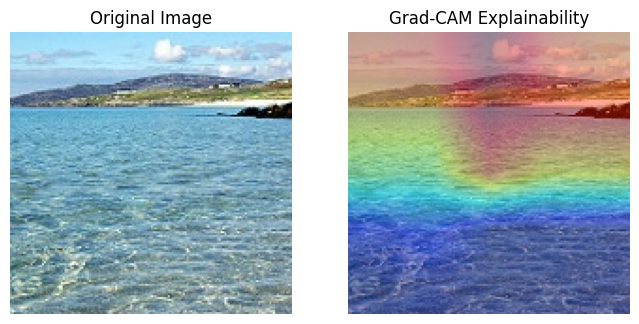

In [22]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

def generate_gradcam(img_array, model):
    # Locate the nested backbone and its last convolutional layer
    mobilenet_layer = model.get_layer('mobilenetv2_1.00_224')
    last_conv = mobilenet_layer.get_layer('Conv_1')

    # Reconstruct sub-pipeline up to Conv_1
    sub_input = tf.keras.Input(shape=(150, 150, 3))
    x = model.get_layer('data_augmentation')(sub_input) if 'data_augmentation' in [l.name for l in model.layers] else sub_input

    # Trace features through the backbone manually to obtain Conv_1 output
    # Create an intermediate model out of the inner MobileNet backbone
    backbone_grad_model = tf.keras.models.Model(
        inputs=mobilenet_layer.inputs,
        outputs=last_conv.output
    )

    with tf.GradientTape() as tape:
        # Cast input array to float tensor
        img_tensor = tf.cast(img_array, tf.float32)

        # Track conv features and final predictions through tape
        conv_outputs = backbone_grad_model(tf.keras.applications.mobilenet_v2.preprocess_input(img_tensor))
        tape.watch(conv_outputs)

        # Pass remaining top layers (GAP, Dropout, Dense)
        x = conv_outputs
        for layer in model.layers:
            if layer.name not in ['input_layer_5', 'data_augmentation', 'mobilenetv2_1.00_224']:
                x = layer(x)
        predictions = x

        top_class_idx = tf.argmax(predictions[0])
        loss = predictions[:, top_class_idx]

    # Compute gradients of class output w.r.t. feature map
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature map channels by gradient importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Test and visual result display
sample_file = os.listdir(pred_dir)[0]
sample_img_path = os.path.join(pred_dir, sample_file)

raw_img = Image.open(sample_img_path).convert('RGB').resize((150, 150))
img_array = np.expand_dims(np.array(raw_img), axis=0)

# Generate Heatmap
heatmap = generate_gradcam(img_array, model_transfer)

# Resize heatmap and apply color overlay
heatmap_resized = cv2.resize(heatmap, (150, 150))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

# Overlay heatmap onto original image
superimposed_img = cv2.addWeighted(np.array(raw_img), 0.6, heatmap_colored, 0.4, 0)

# Display Visual Results
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Explainability")
plt.axis('off')
plt.show()

#**This part os going to be used to use the model without re-training**

In [23]:
import tensorflow as tf
from PIL import Image
import numpy as np

# Reload the saved model from disk
reloaded_model = tf.keras.models.load_model("intel_scene_classifier_mobilenetv2.keras")

# Test prediction with the reloaded model
sample_img = Image.open(sample_img_path).convert('RGB').resize((150, 150))
input_tensor = np.expand_dims(np.array(sample_img), axis=0)

predictions = reloaded_model.predict(input_tensor, verbose=0)
pred_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print(f"Reloaded Model Prediction: {pred_class} ({confidence:.2f}% confidence)")

Reloaded Model Prediction: sea (99.81% confidence)


# For an external image

In [27]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the saved model and define class labels
reloaded_model = tf.keras.models.load_model("intel_scene_classifier_mobilenetv2.keras")
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# 2. Function to predict on a custom image file path
def predict_external_image(image_path, model, class_names):
    if not os.path.exists(image_path):
        print(f"Error: File not found at {image_path}")
        return

    # Load image, convert to RGB, and resize to 150x150
    raw_img = Image.open(image_path).convert('RGB')
    resized_img = raw_img.resize((150, 150))

    # Convert image to numpy array and add batch dimension (1, 150, 150, 3)
    img_array = np.array(resized_img)
    input_tensor = np.expand_dims(img_array, axis=0)

    # Generate model prediction
    predictions = model.predict(input_tensor, verbose=0)
    top_idx = np.argmax(predictions[0])
    predicted_class = class_names[top_idx]
    confidence = predictions[0][top_idx] * 100

    # Display image with prediction title
    plt.figure(figsize=(4, 4))
    plt.imshow(raw_img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()



For Jupyter Notebook using the image path

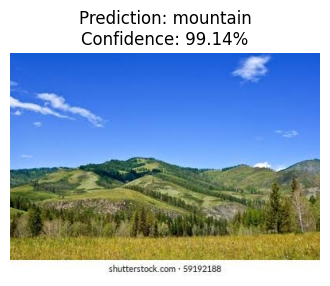

In [28]:
# 3. Pass any local image path on your machine
external_image_path = "Test_Mountain.jpeg"  # Replace with your image path

predict_external_image(external_image_path, reloaded_model, class_names)

For Colab using direct upload

Saving Test_Forest.jpeg to Test_Forest (1).jpeg


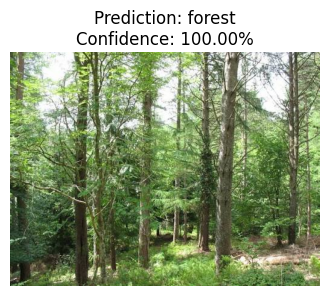

In [29]:
from google.colab import files
uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]

# Run prediction on uploaded file
predict_external_image(uploaded_filename, reloaded_model, class_names)